In [7]:
import pandas as pd
import numpy as pd

In [5]:
df = pd.read_csv('/placement-dataset.csv')

In [9]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [10]:
df.shape

(100, 4)

In [ ]:
# steps

# 0. preprocess + EDA + Feature selection
# 1. Extract input and output cols
# 2. scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [12]:
# remove unnamed coloum

df = df.iloc[:,1:]

In [13]:
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [14]:
# EDA (Exploratory Data Analysis)

import matplotlib.pyplot as plt


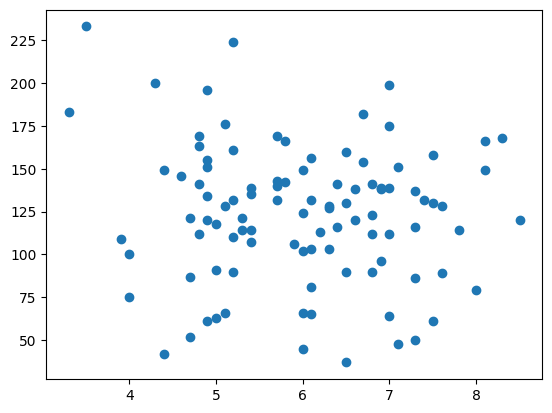

In [15]:
plt.scatter(df['cgpa'],df['iq'])

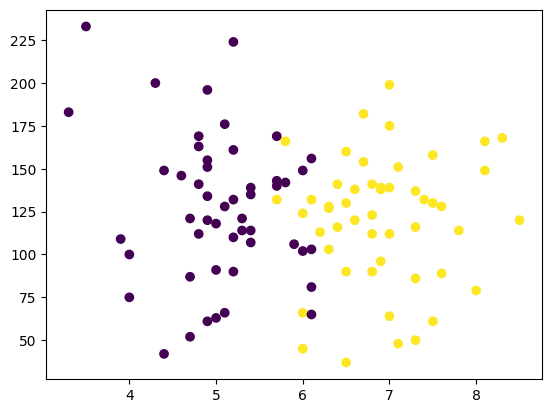

In [19]:
# bule color placement = NO
# yellow color placement = YES

plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [20]:
# 1. Extract input and output cols

x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [21]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [22]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [23]:
y.shape

(100,)

In [30]:
# 3. Train test split

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

In [26]:
x_train

,cgpa,iq
14,6.1,103.0
17,3.3,183.0
29,7.0,112.0
43,6.8,141.0
82,6.5,37.0
...,...,...
7,5.0,63.0
10,6.0,45.0
25,5.0,91.0
16,5.2,224.0


In [27]:
y_train

,placement
14,0
17,0
29,1
43,1
82,1
...,...
7,0
10,1
25,0
16,0


In [31]:
x_test

,cgpa,iq
15,5.1,176.0
94,4.7,52.0
18,4.0,100.0
25,5.0,91.0
23,4.7,87.0
40,4.9,134.0
13,6.4,116.0
10,6.0,45.0
81,5.4,107.0
4,5.8,142.0


In [32]:
y_train

,placement
96,0
12,0
5,1
34,0
67,0
...,...
52,1
69,1
49,0
26,1


In [34]:
# 2. scale the values

from sklearn.preprocessing import StandardScaler


In [35]:
scaler = StandardScaler()

In [36]:
x_train = scaler.fit_transform(x_train)

In [37]:
x_train

array([[-1.46641747, -2.12234621],
       [-0.59297225,  0.33887621],
       [ 0.89188461, -1.97010565],
       [-1.11703938,  0.94783846],
       [-0.94235034, -0.19396575],
       [ 0.45516201,  0.31350279],
       [-0.59297225, -0.29545946],
       [-1.2043839 , -0.11784547],
       [ 1.06657366, -0.24471261],
       [ 0.80454009,  0.33887621],
       [ 1.2412627 ,  0.82097133],
       [-2.25251816,  2.72397836],
       [ 1.50329626, -0.29545946],
       [ 0.54250653,  1.42993358],
       [ 0.71719557,  0.31350279],
       [-1.55376199,  1.88665526],
       [-0.06890512, -0.59994059],
       [-0.33093869,  1.10007903],
       [-1.46641747,  0.59261049],
       [-1.02969486,  0.64335734],
       [ 0.0184394 ,  0.16126223],
       [ 0.62985105, -0.34620632],
       [-0.68031677, -0.29545946],
       [ 1.06657366, -1.00591542],
       [ 0.36781748, -0.90442171],
       [ 0.54250653,  0.71947762],
       [-1.02969486, -0.1432189 ],
       [-0.06890512,  0.59261049],
       [ 0.19312844,

In [38]:
x_test = scaler.transform(x_test)

In [39]:
x_test

array([[-0.85500582,  1.27769302],
       [-1.2043839 , -1.86861194],
       [-1.81579555, -0.65068744],
       [-0.94235034, -0.87904828],
       [-1.2043839 , -0.98054199],
       [-1.02969486,  0.21200908],
       [ 0.28047296, -0.24471261],
       [-0.06890512, -2.04622593],
       [-0.59297225, -0.47307345],
       [-0.24359417,  0.4149965 ]])

In [40]:
# 4. Train the model

from sklearn.linear_model import LogisticRegression

In [41]:
clf = LogisticRegression()

In [47]:
# model trainning

clf.fit(x_train,y_train)


LogisticRegression()

In [50]:
# 5. Evaluate the model/model selection

y_pred = clf.predict(x_test)

In [49]:
y_test

,placement
15,0
94,0
18,0
25,0
23,0
40,0
13,1
10,1
81,0
4,0


In [52]:
from sklearn.metrics import accuracy_score

In [53]:
accuracy_score(y_test,y_pred)

0.9

In [54]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

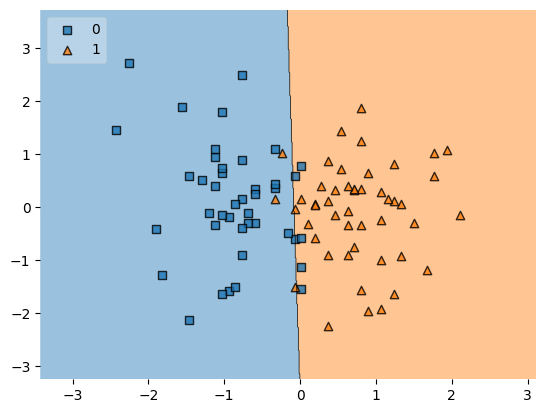

In [56]:
plot_decision_regions(x_train,y_train.values, clf=clf, legend=2)

In [57]:
import pickle

In [60]:
pickle.dump(clf,open('model.pkl','wb'))